<a href="https://colab.research.google.com/github/MahdiMashayekhi-AI/Machine-Learning-Projects/blob/main/02-supervised-learning/02-regression/Student-Score-Prediction/Student_Score_Prediction.ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student Score Prediction Project

This project aims to build a regression model to predict student scores using Python and relevant libraries.

## Import Libraries

Import all necessary libraries for the pipeline, at least 11-12 different regression models for model selection, all regression evaluation metrics, and tools for Grid Search and Cross-Validation.

In [74]:
# Import necessary libraries

# Data manipulation
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Preprocessing and pipeline
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import RobustScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.2f}'.format)

print("Libraries imported successfully.")

Libraries imported successfully.


## Data Loading

Load the dataset (the file path is not needed at this stage).

In [15]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "StudentPerformanceFactors.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "lainguyn123/student-performance-factors",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

In [16]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


## EDA

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [18]:
print(f"Number of rows in dataset is: {df.shape[0]}")
print(f"Number of cols in dataset is: {df.shape[1]}")

Number of rows in dataset is: 6607
Number of cols in dataset is: 20


In [109]:
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

In [19]:
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [27]:
null_percentage = (df.isnull().sum() / df.shape[0] * 100).sort_values(ascending=False)
print(null_percentage[null_percentage > 0])

Parental_Education_Level   1.36
Teacher_Quality            1.18
Distance_from_Home         1.01
dtype: float64


In [28]:
print(f"Total number NaN value is: {df.isnull().sum().sum()}")

Total number NaN value is: 235


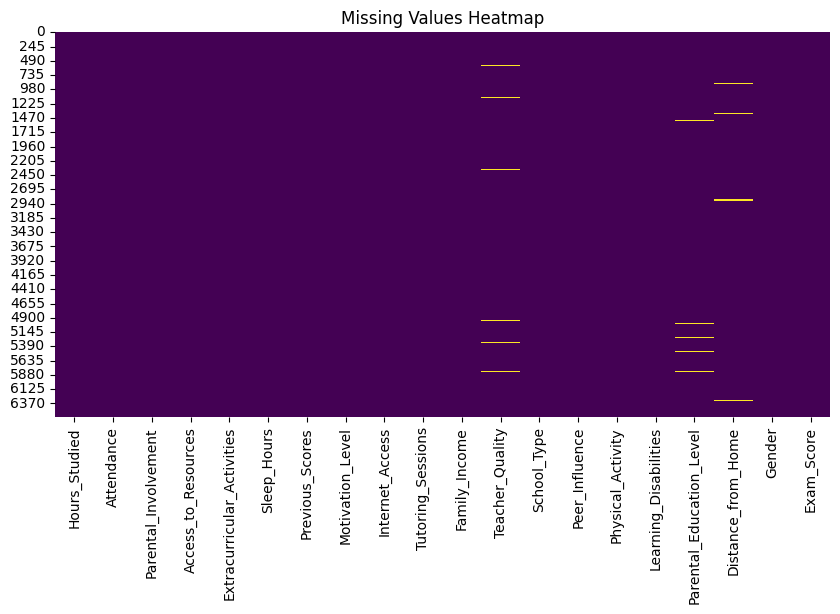

In [43]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [30]:
print(f"Number of duplicate values is: {df.duplicated().sum()}")

Number of duplicate values is: 0


In [32]:
corr_matrix = df.select_dtypes(include=['number']).corr()
corr_matrix

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
Hours_Studied,1.00,-0.01,0.01,0.02,-0.01,0.00,0.45
Attendance,-0.01,1.00,-0.02,-0.02,0.01,-0.02,0.58
Sleep_Hours,0.01,-0.02,1.00,-0.02,-0.01,-0.00,-0.02
Previous_Scores,0.02,-0.02,-0.02,1.00,-0.01,-0.01,0.18
Tutoring_Sessions,-0.01,0.01,-0.01,-0.01,1.00,0.02,0.16
Physical_Activity,0.00,-0.02,-0.00,-0.01,0.02,1.00,0.03
Exam_Score,0.45,0.58,-0.02,0.18,0.16,0.03,1.00


In [35]:
corr_matrix['Exam_Score'].sort_values(ascending=False)

,Exam_Score
Exam_Score,1.00
Attendance,0.58
Hours_Studied,0.45
Previous_Scores,0.18
Tutoring_Sessions,0.16
Physical_Activity,0.03
Sleep_Hours,-0.02


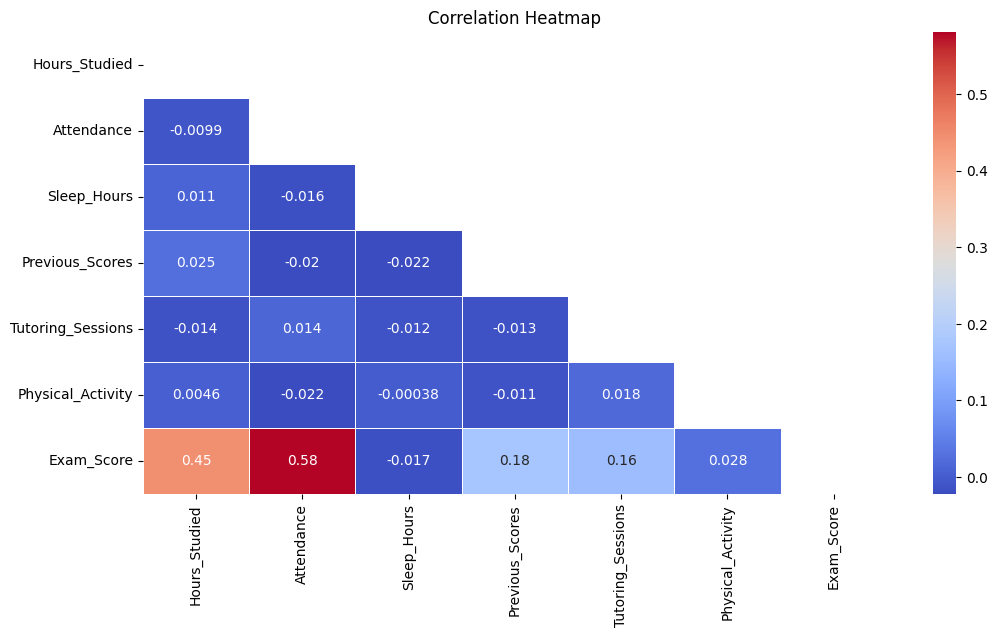

In [44]:
plt.figure(figsize=(12, 6))
mask = np.triu(np.ones_like(corr_matrix))
sns.heatmap(corr_matrix, annot=True, mask=mask, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [60]:
num_cols = df.select_dtypes(include=['number']).columns
cat_cols = df.select_dtypes(exclude=['number']).columns

In [48]:
def plot_distribution(column_name, df=df):
    if column_name not in df.columns:
        print(f"Error: Column '{column_name}' not found in the DataFrame.")
        return

    # Set up the figure and axes
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f'Distribution of {column_name}', fontsize=18)

    # Histogram
    sns.histplot(df[column_name], kde=False, ax=axes[0], color='b')
    axes[0].set_title('Histogram', fontsize=16, fontweight='bold', color='purple')
    axes[0].set_xlabel(column_name)
    axes[0].set_ylabel('Frequency')

    # Density Plot (KDE)
    sns.kdeplot(df[column_name], fill=True, ax=axes[1], color='r')
    axes[1].set_title('Density Plot (KDE)', fontsize=16, fontweight='bold', color='purple')
    axes[1].set_xlabel(column_name)
    axes[1].set_ylabel('Density')

    # Box Plot
    sns.boxplot(y=df[column_name], ax=axes[2], color='g')
    axes[2].set_title('Box Plot', fontsize=16, fontweight='bold', color='purple')
    axes[2].set_ylabel(column_name)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

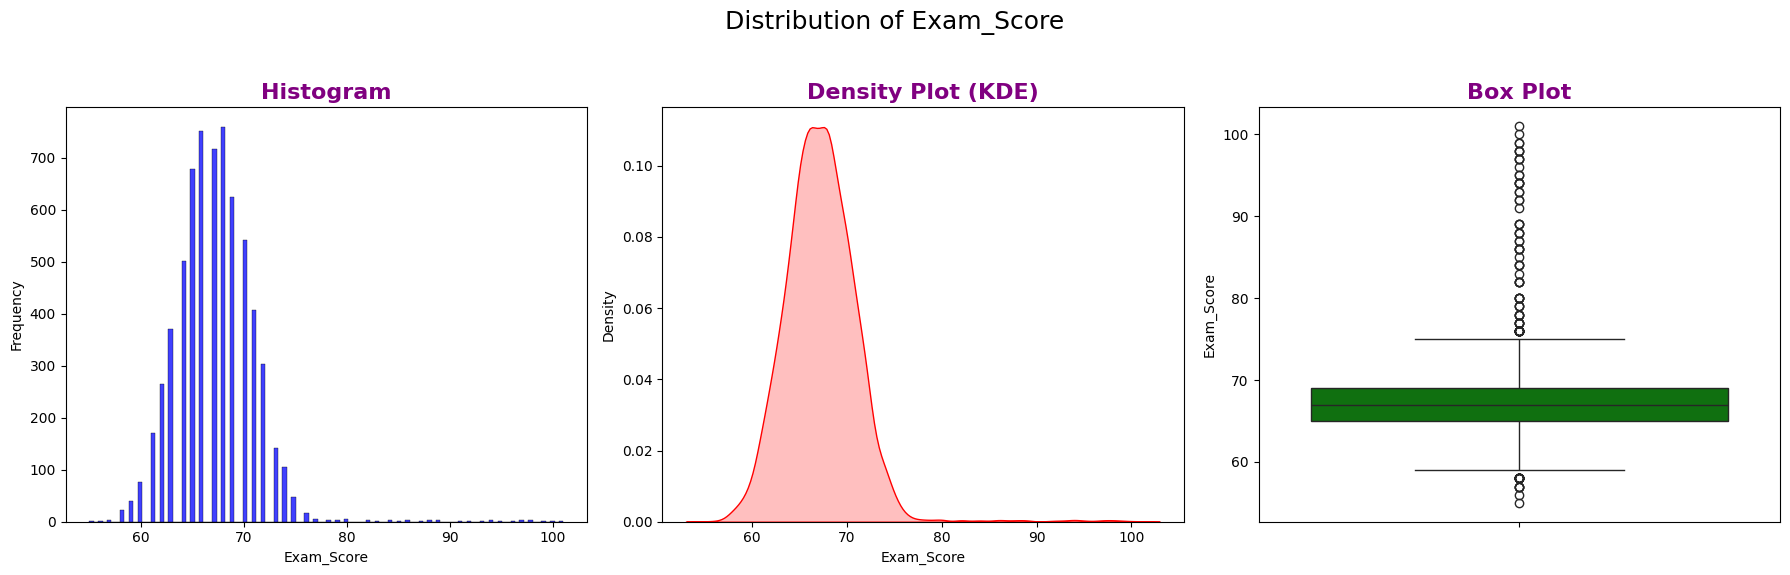

In [49]:
plot_distribution('Exam_Score')

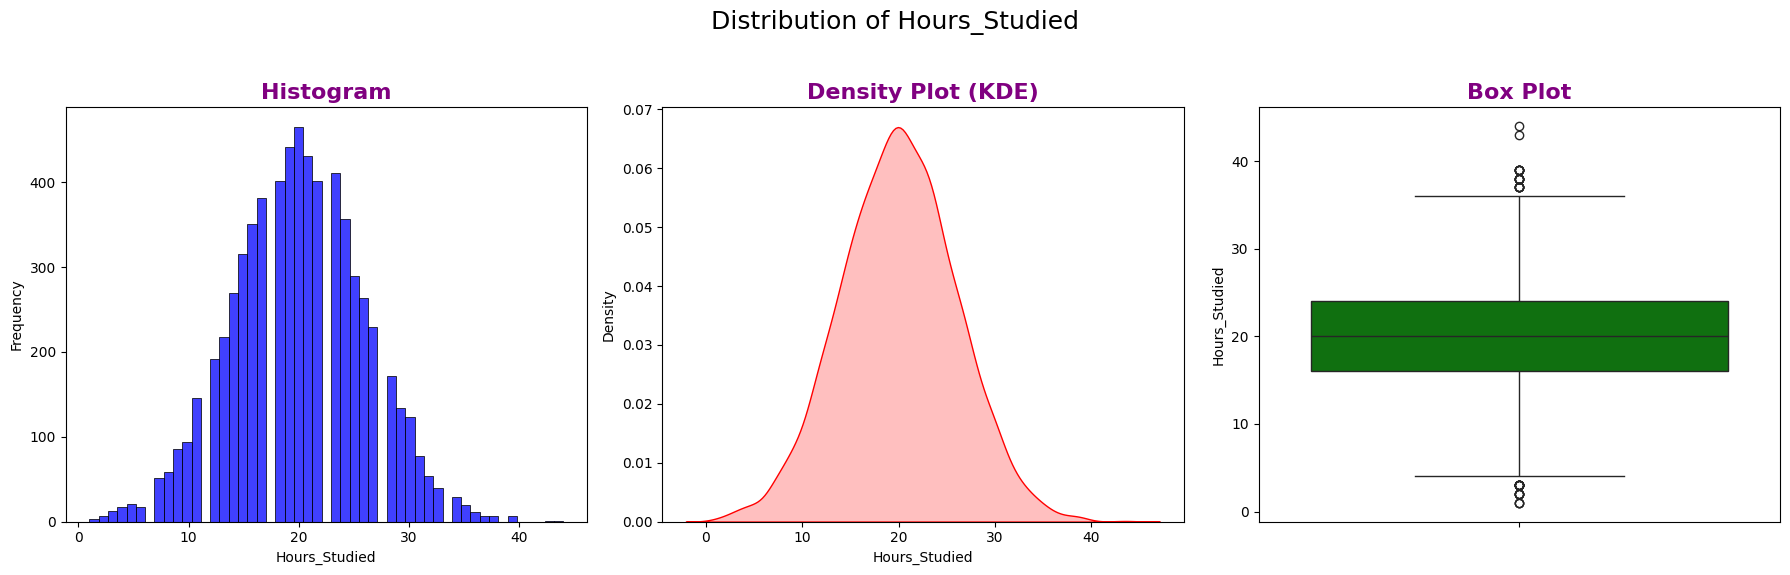

In [53]:
plot_distribution('Hours_Studied')

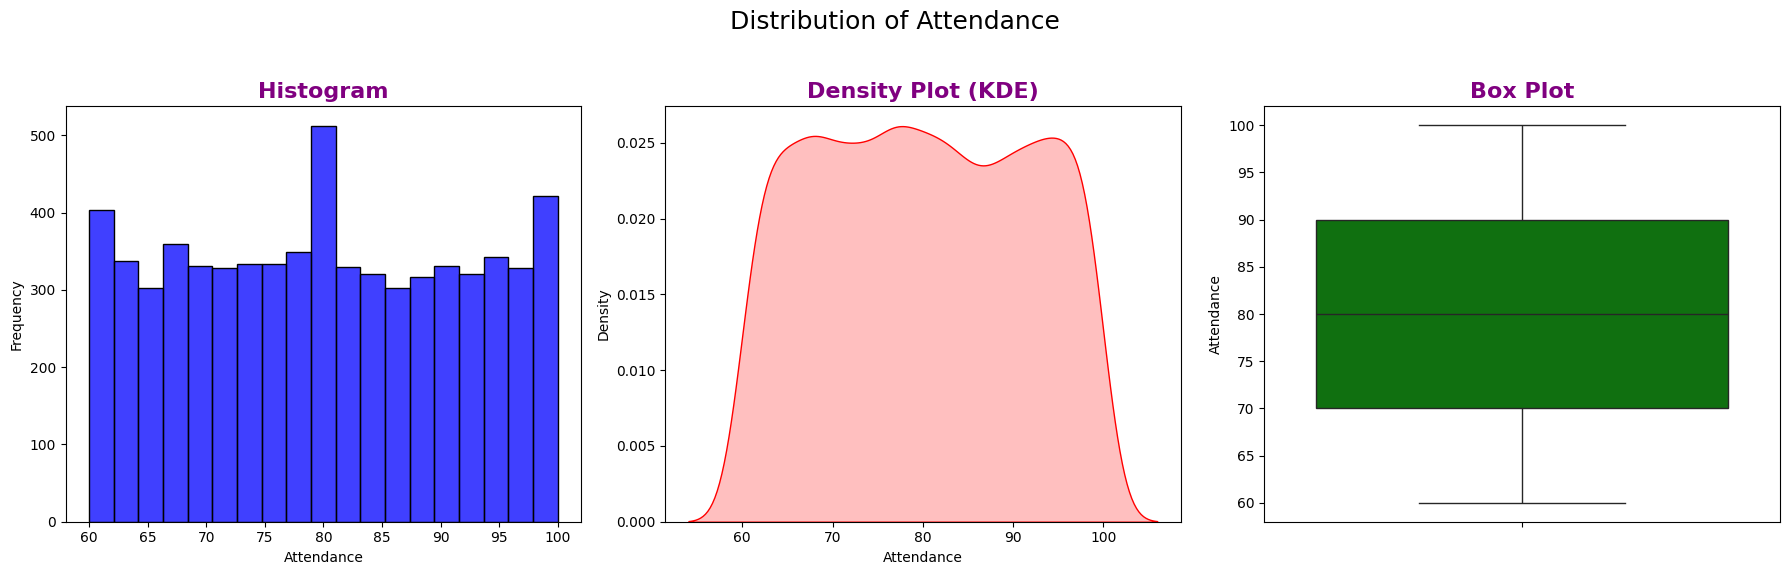

In [54]:
plot_distribution('Attendance')

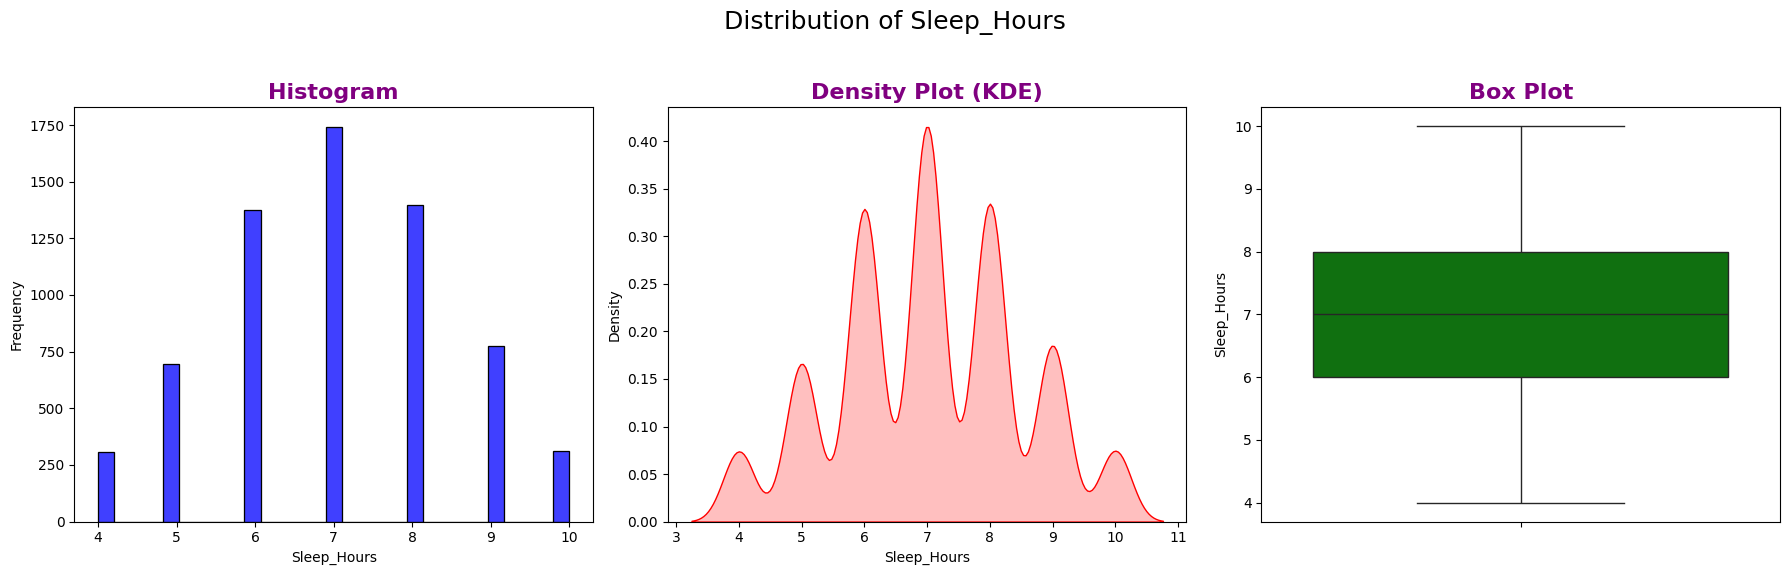

In [55]:
plot_distribution('Sleep_Hours')

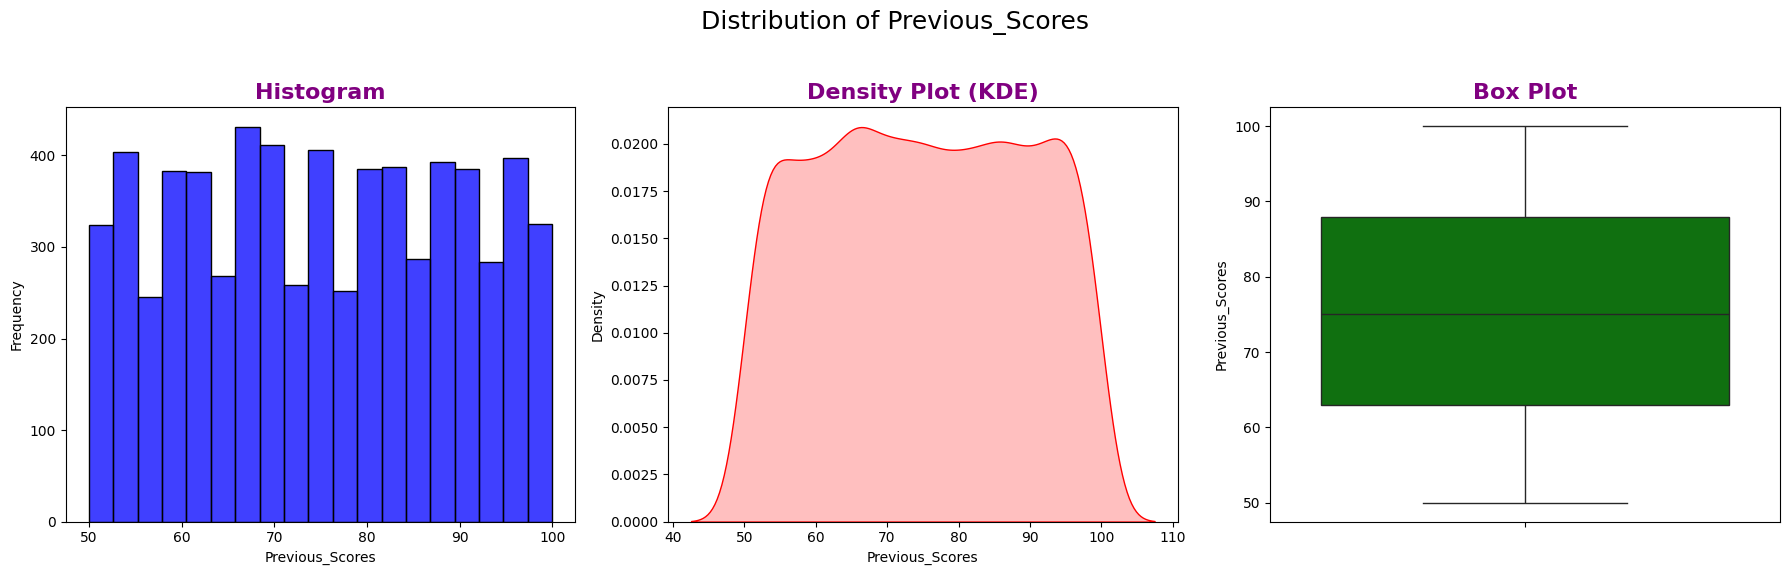

In [56]:
plot_distribution('Previous_Scores')

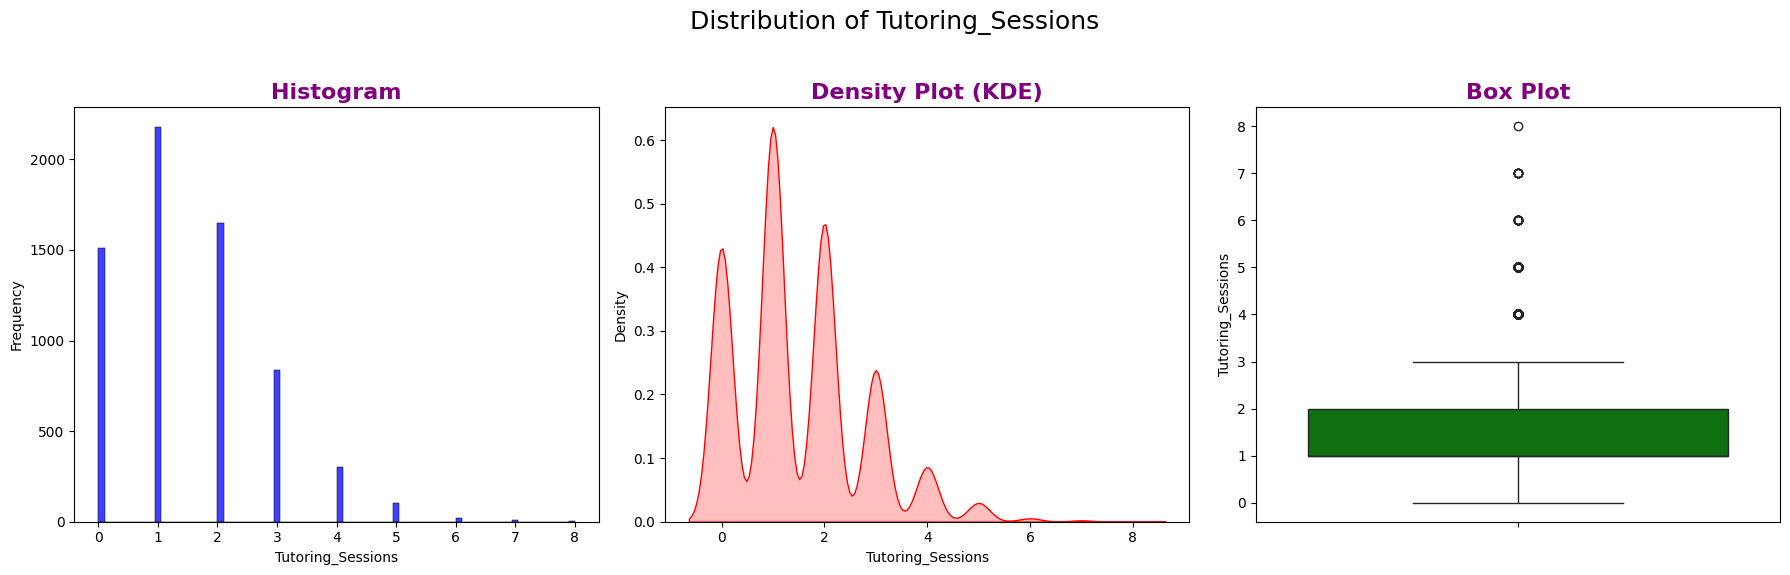

In [57]:
plot_distribution('Tutoring_Sessions')

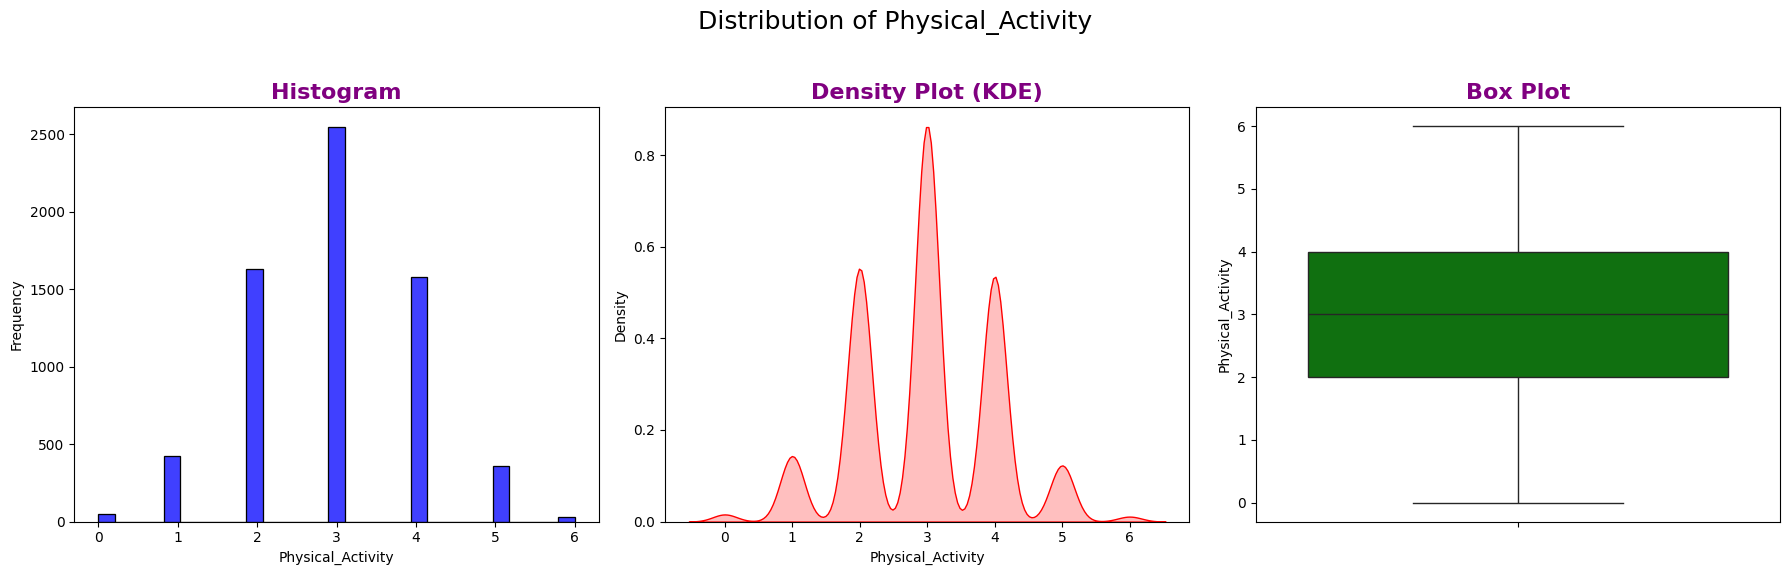

In [58]:
plot_distribution('Physical_Activity')

In [59]:
def plot_categorical_distribution(column_name, df=df):

    if column_name not in df.columns:
        print(f"Error: Column '{column_name}' not found in the DataFrame.")
        return

    # Set up the figure and axes
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    fig.suptitle(f'Distribution of {column_name}', fontsize=16)

    # Count Plot
    sns.countplot(data=df, x=column_name, ax=axes[0], palette='viridis')
    axes[0].set_title('Count Plot')
    axes[0].set_xlabel(column_name)
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=45) # Rotate labels if they overlap

    # Pie Plot
    counts = df[column_name].value_counts()
    axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis', len(counts)))
    axes[1].set_title('Pie Plot')
    axes[1].axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()

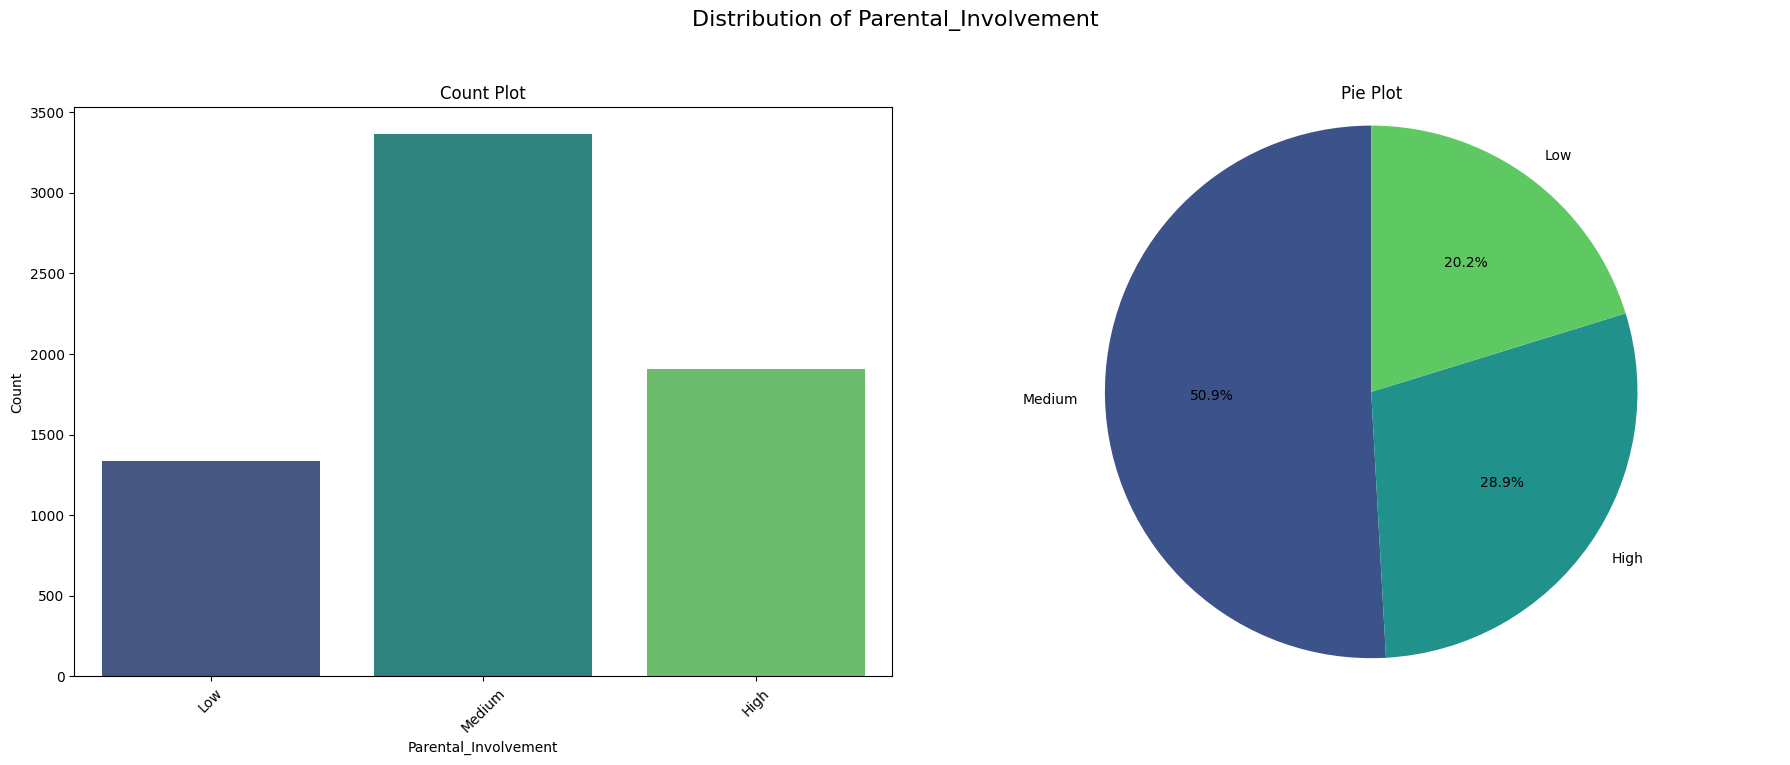

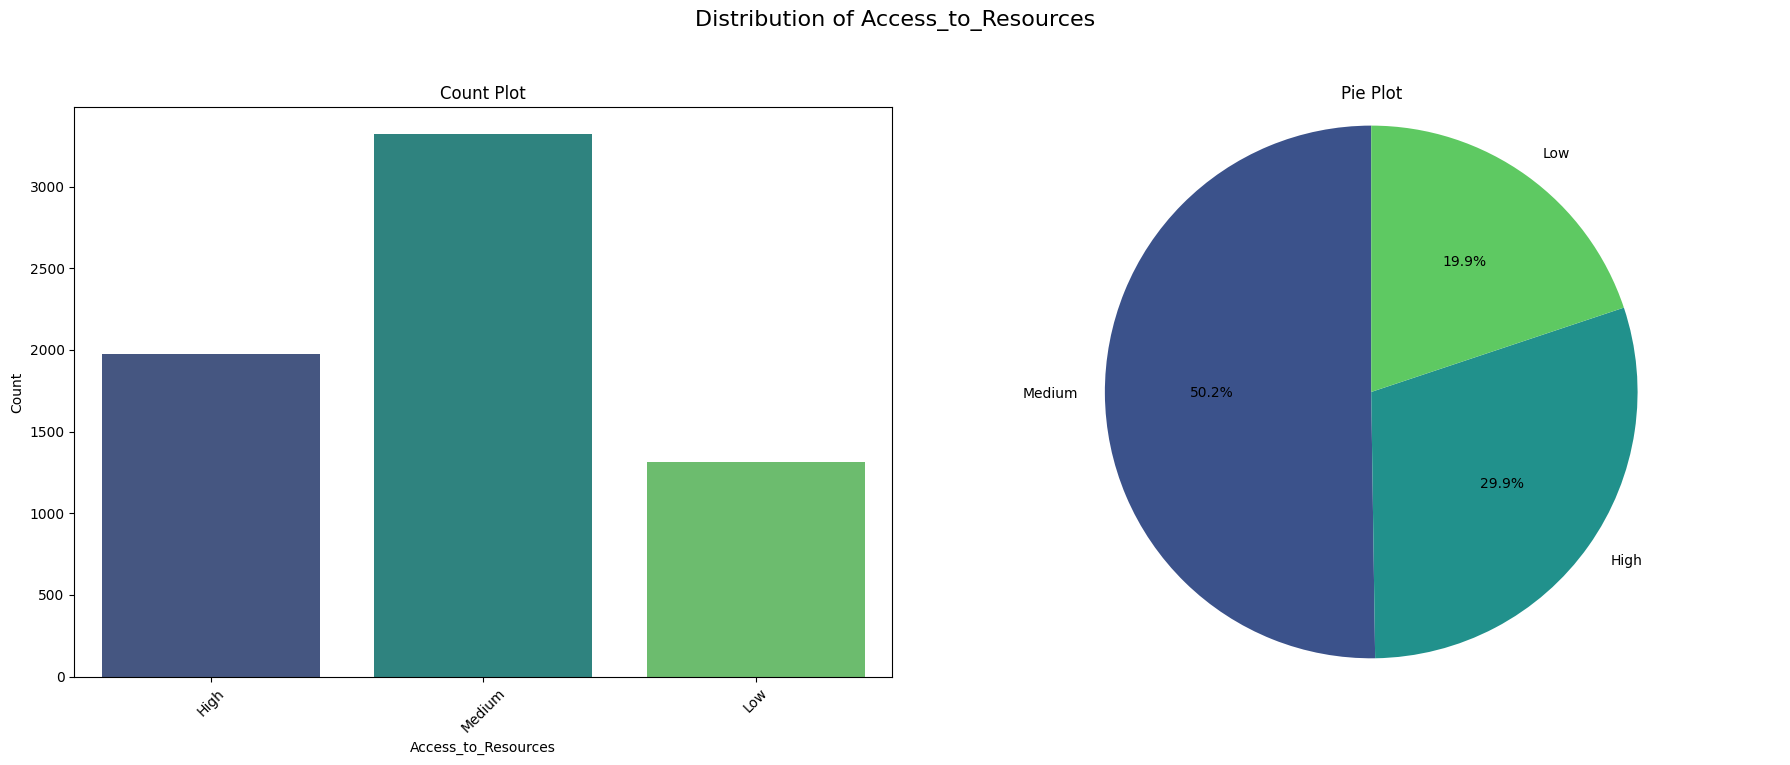

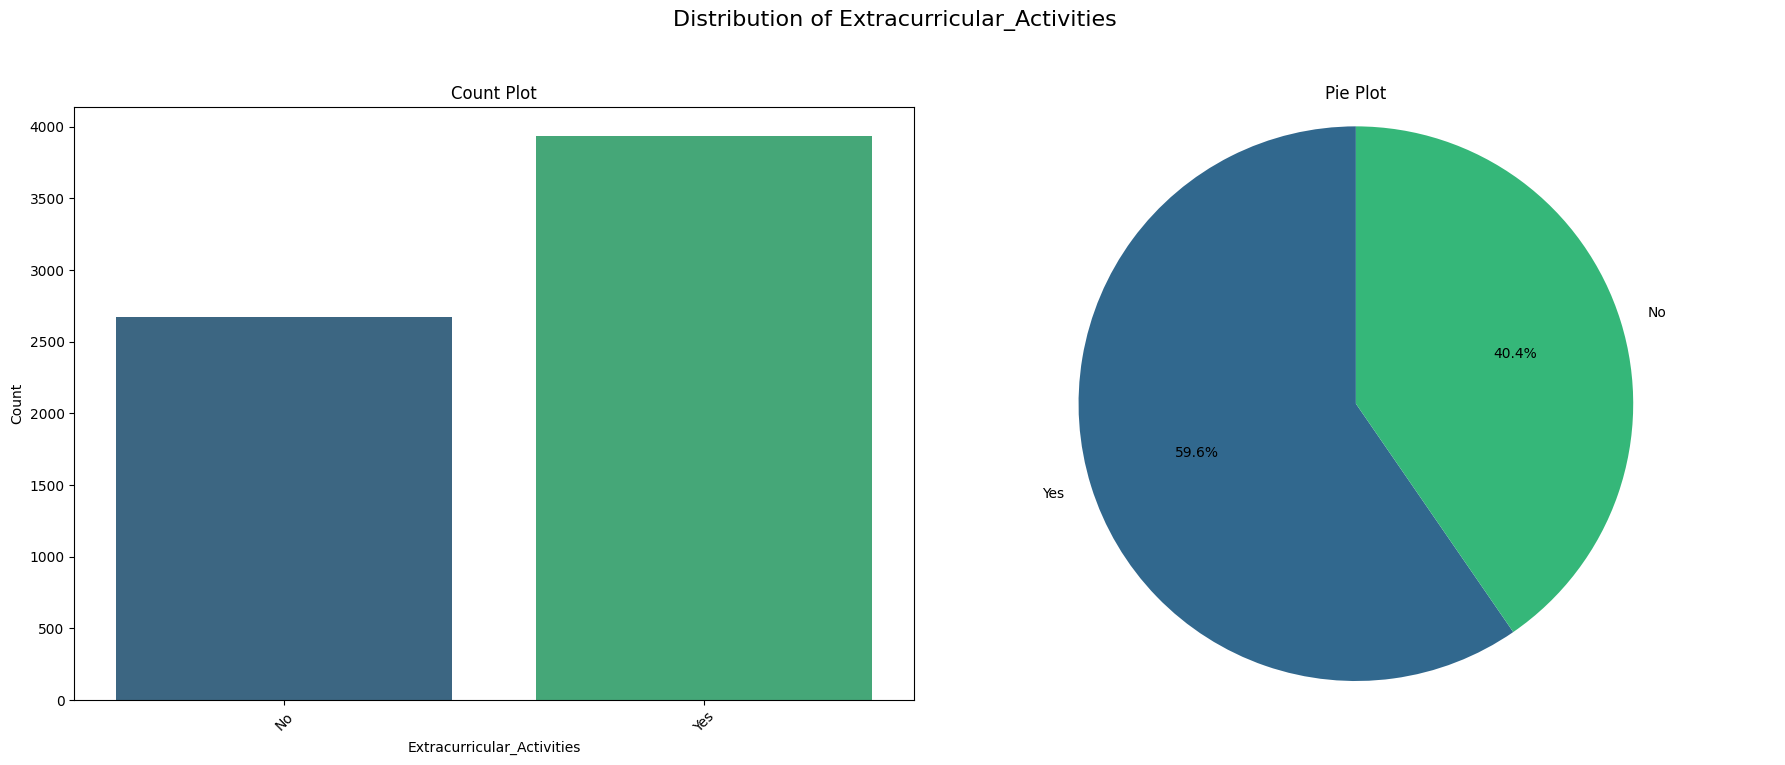

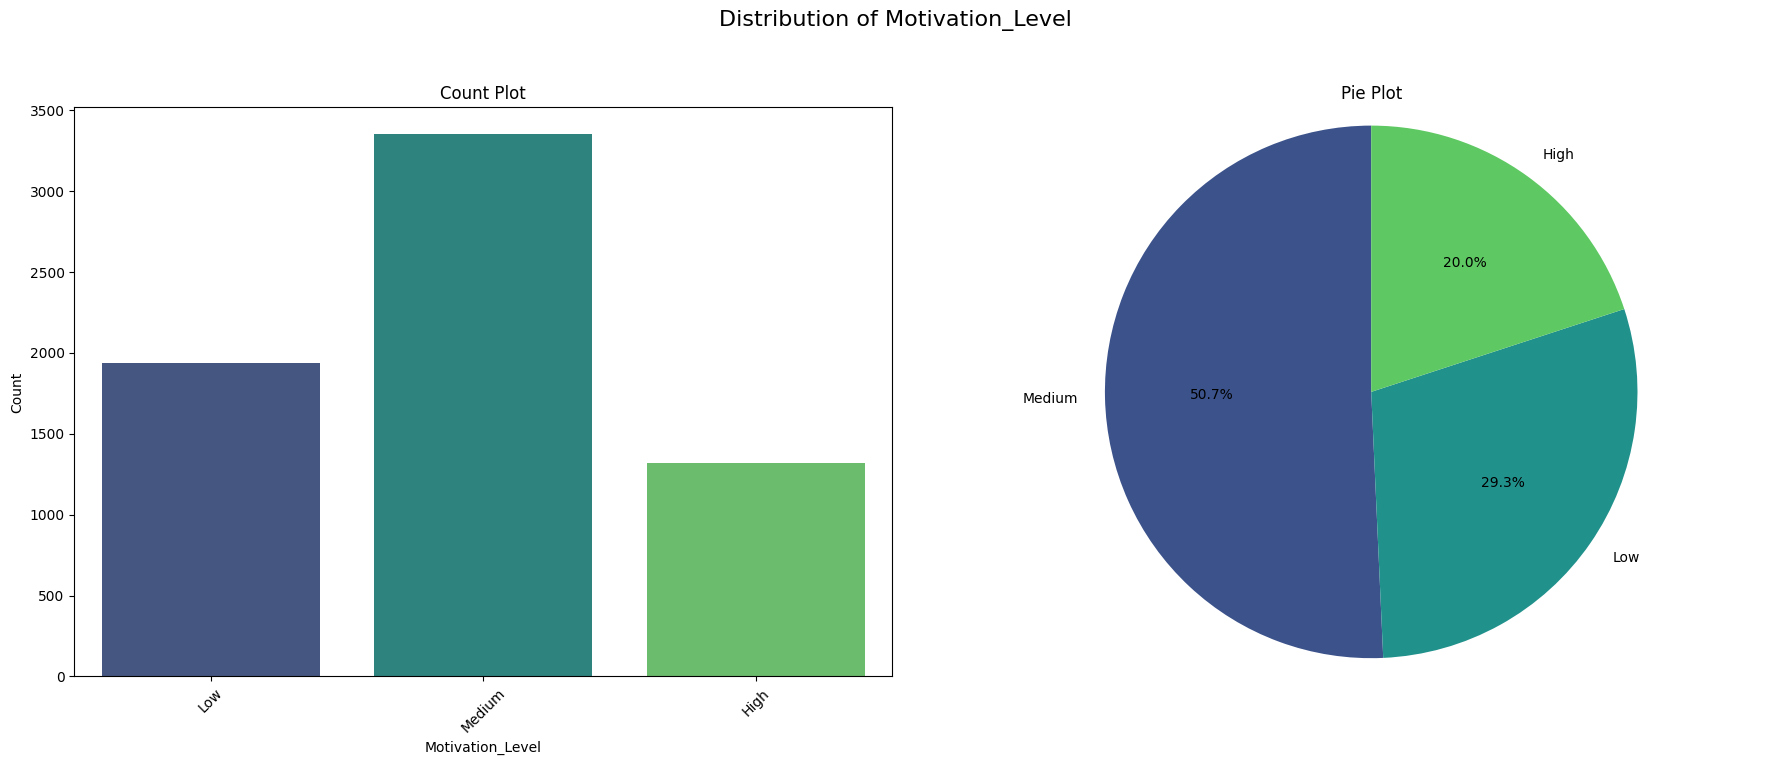

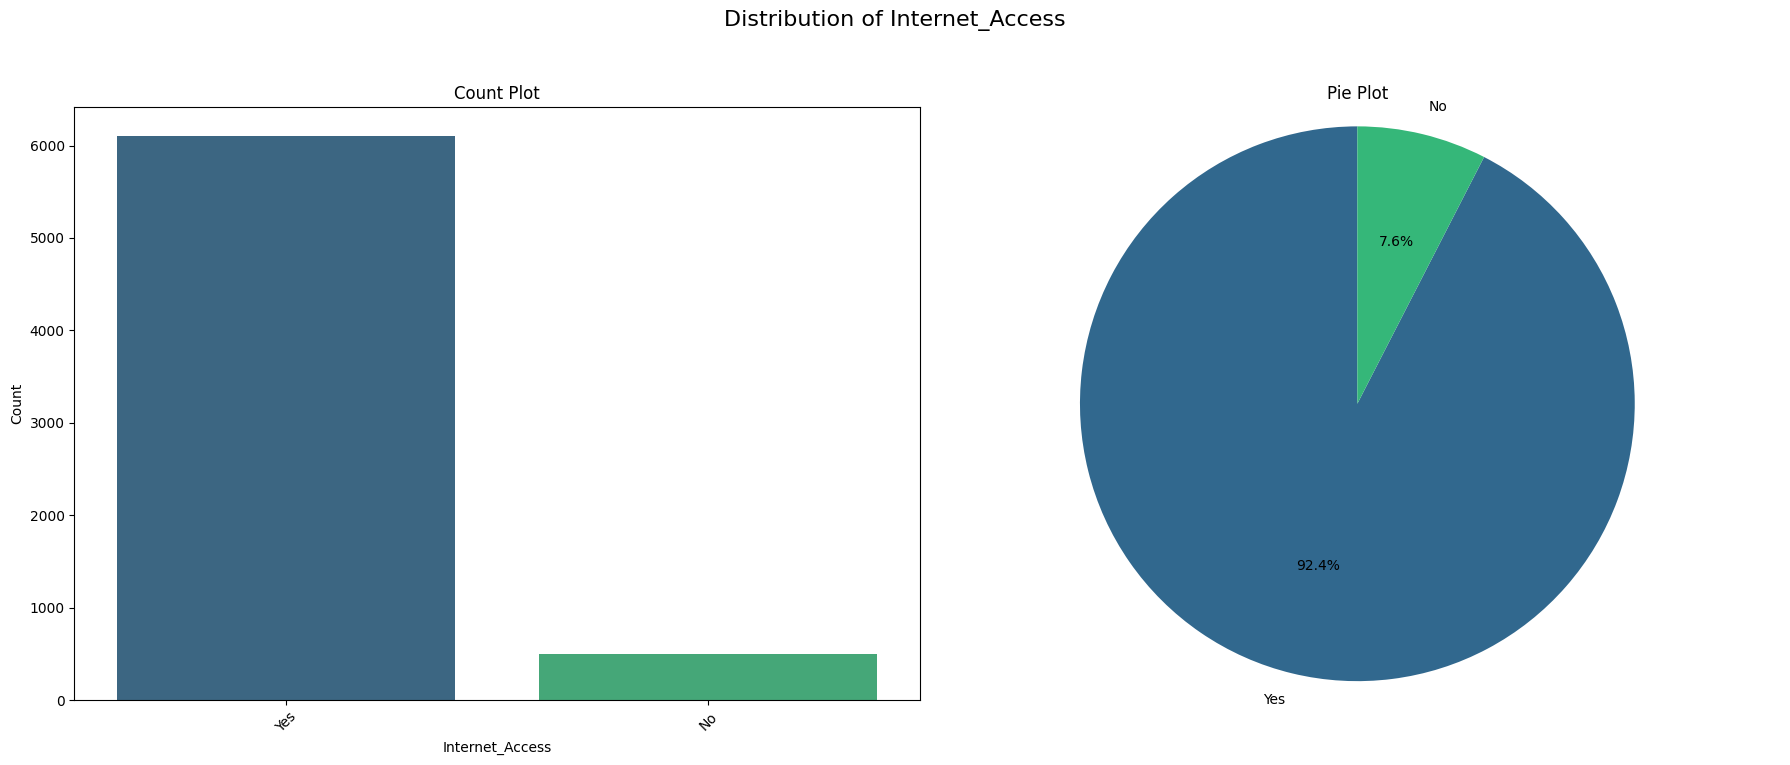

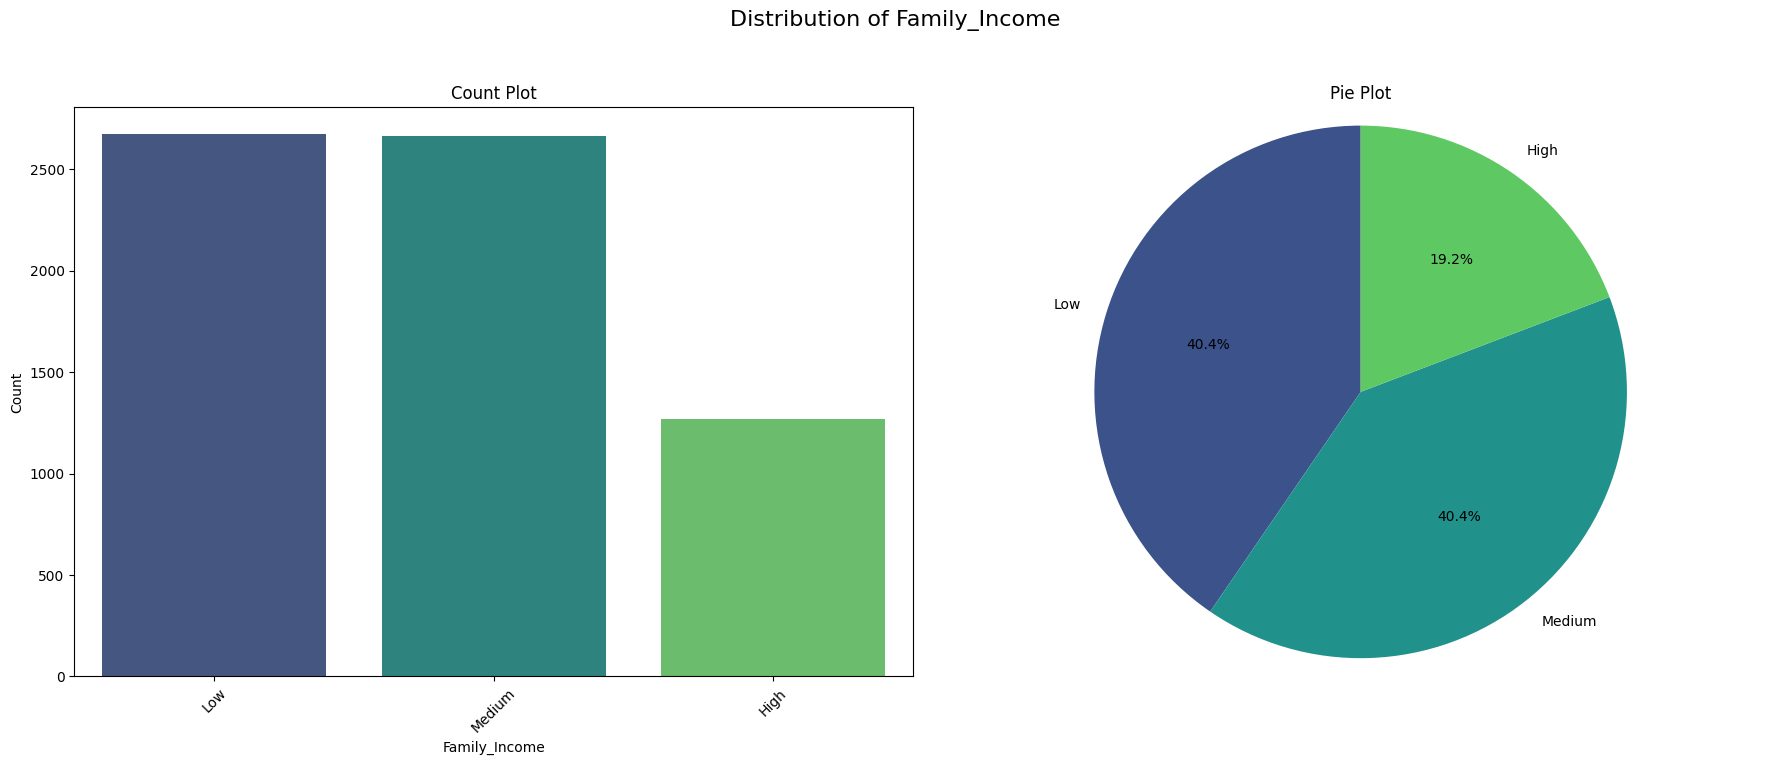

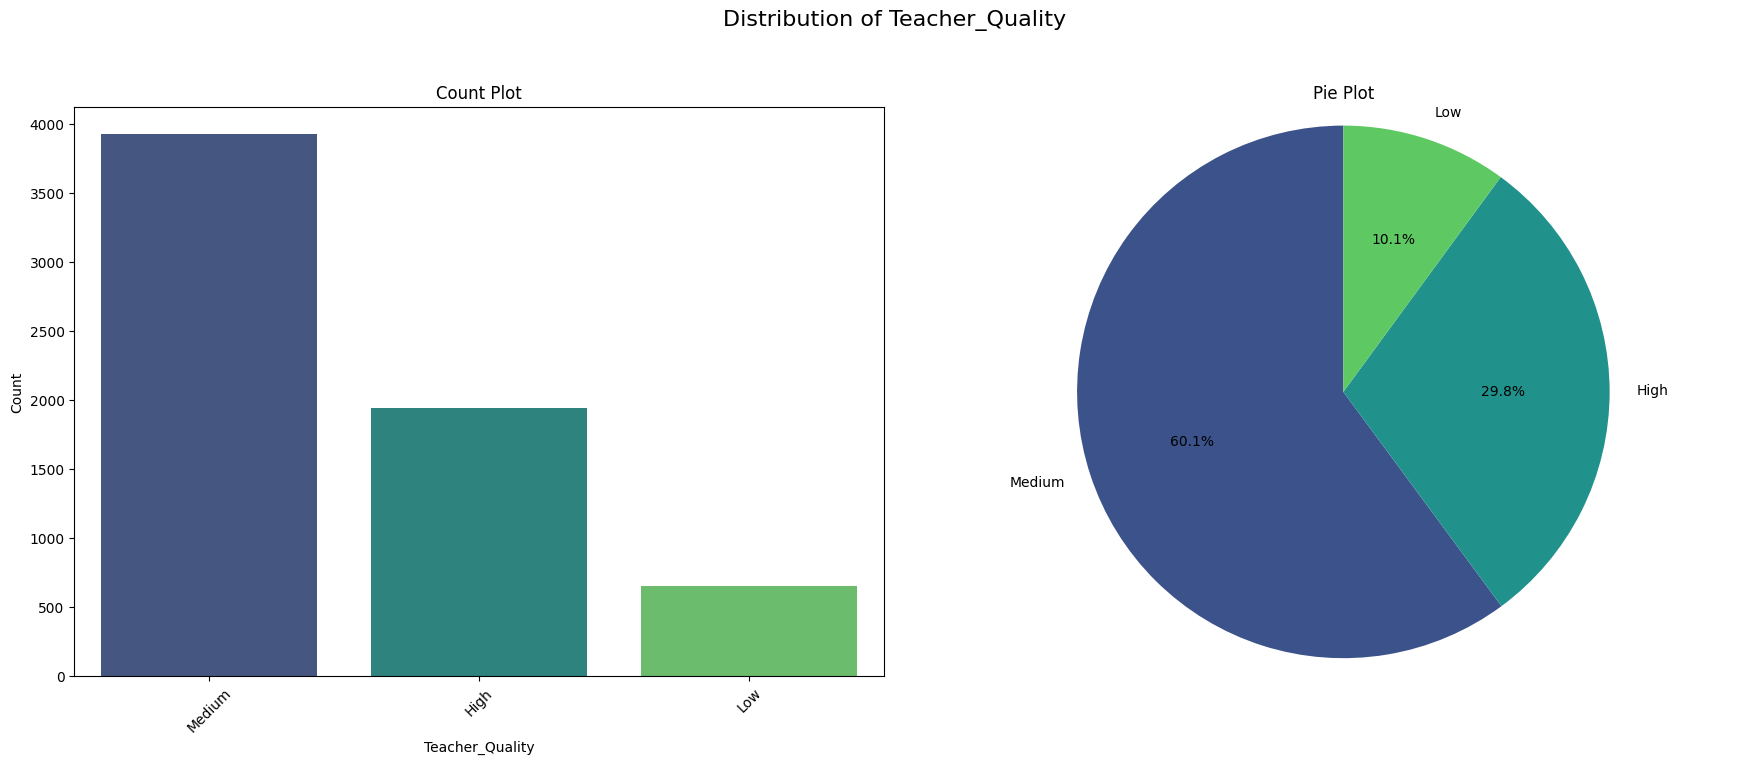

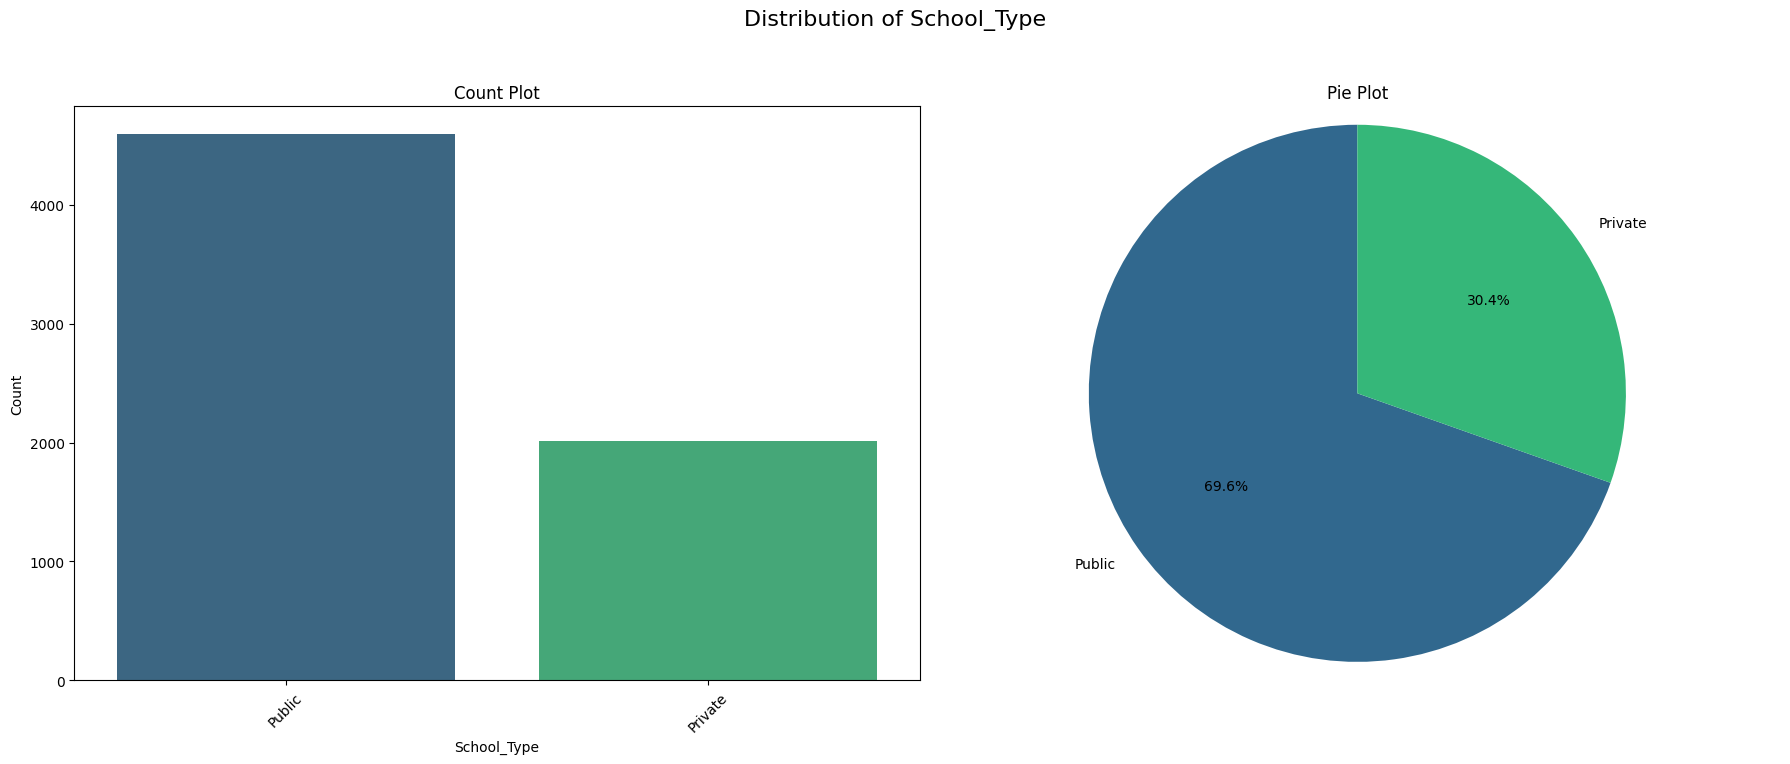

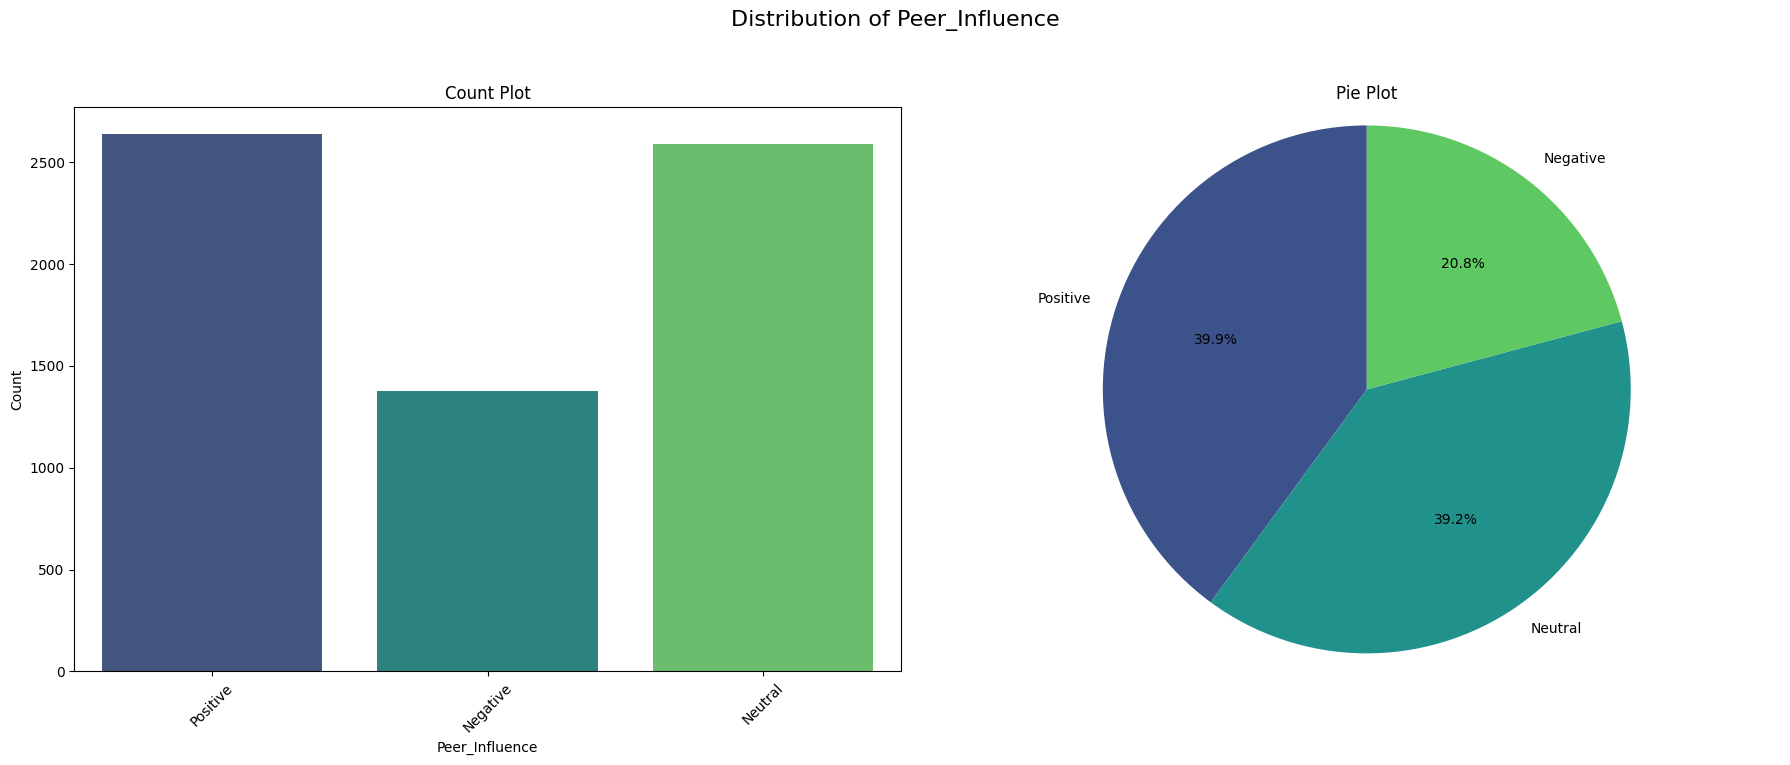

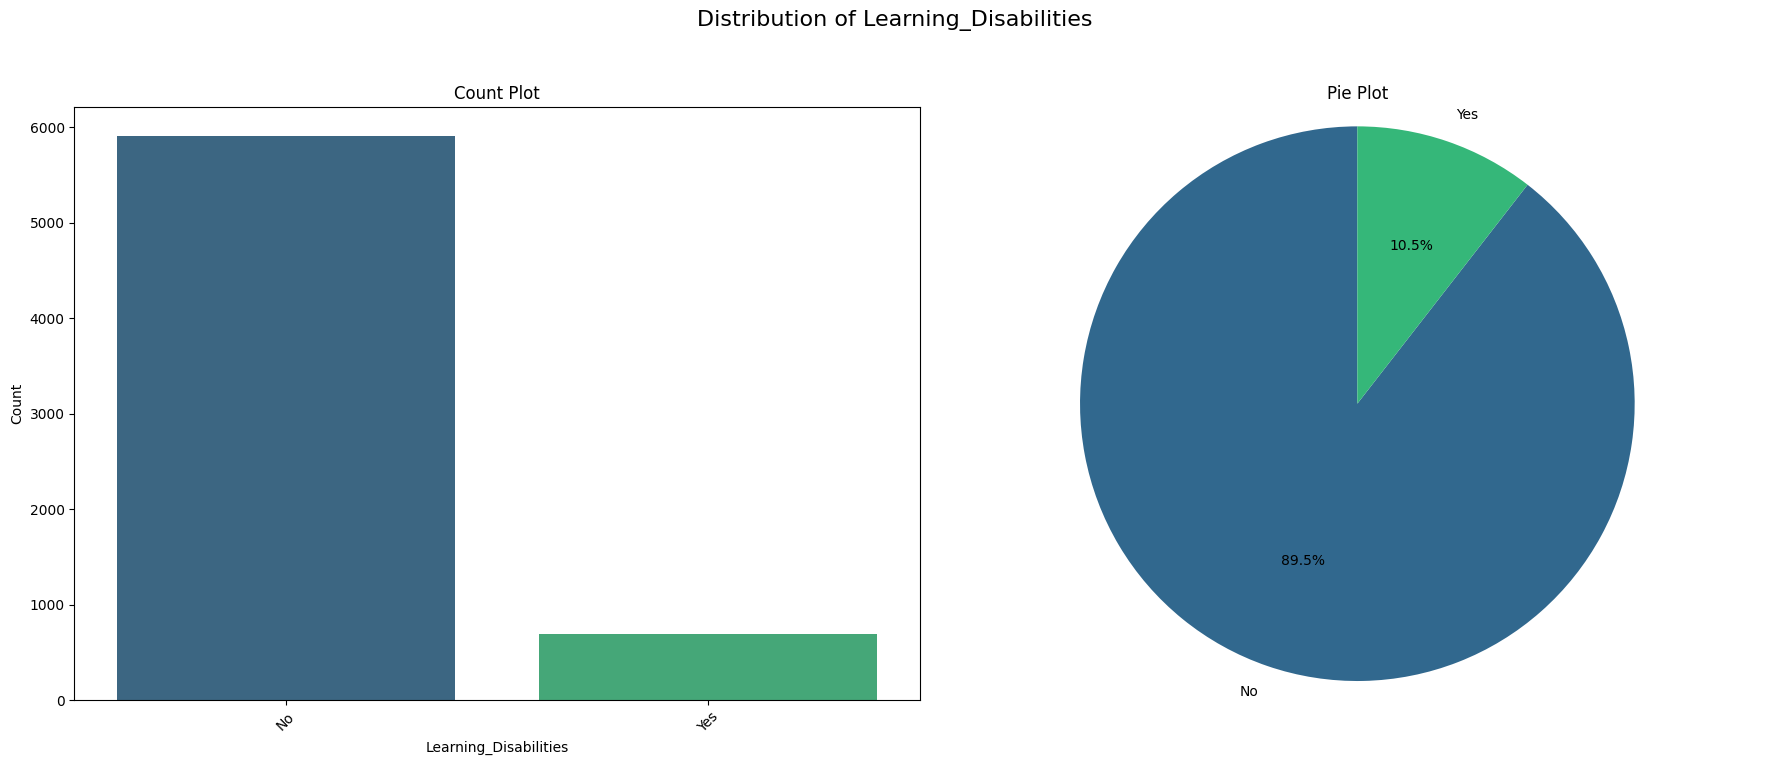

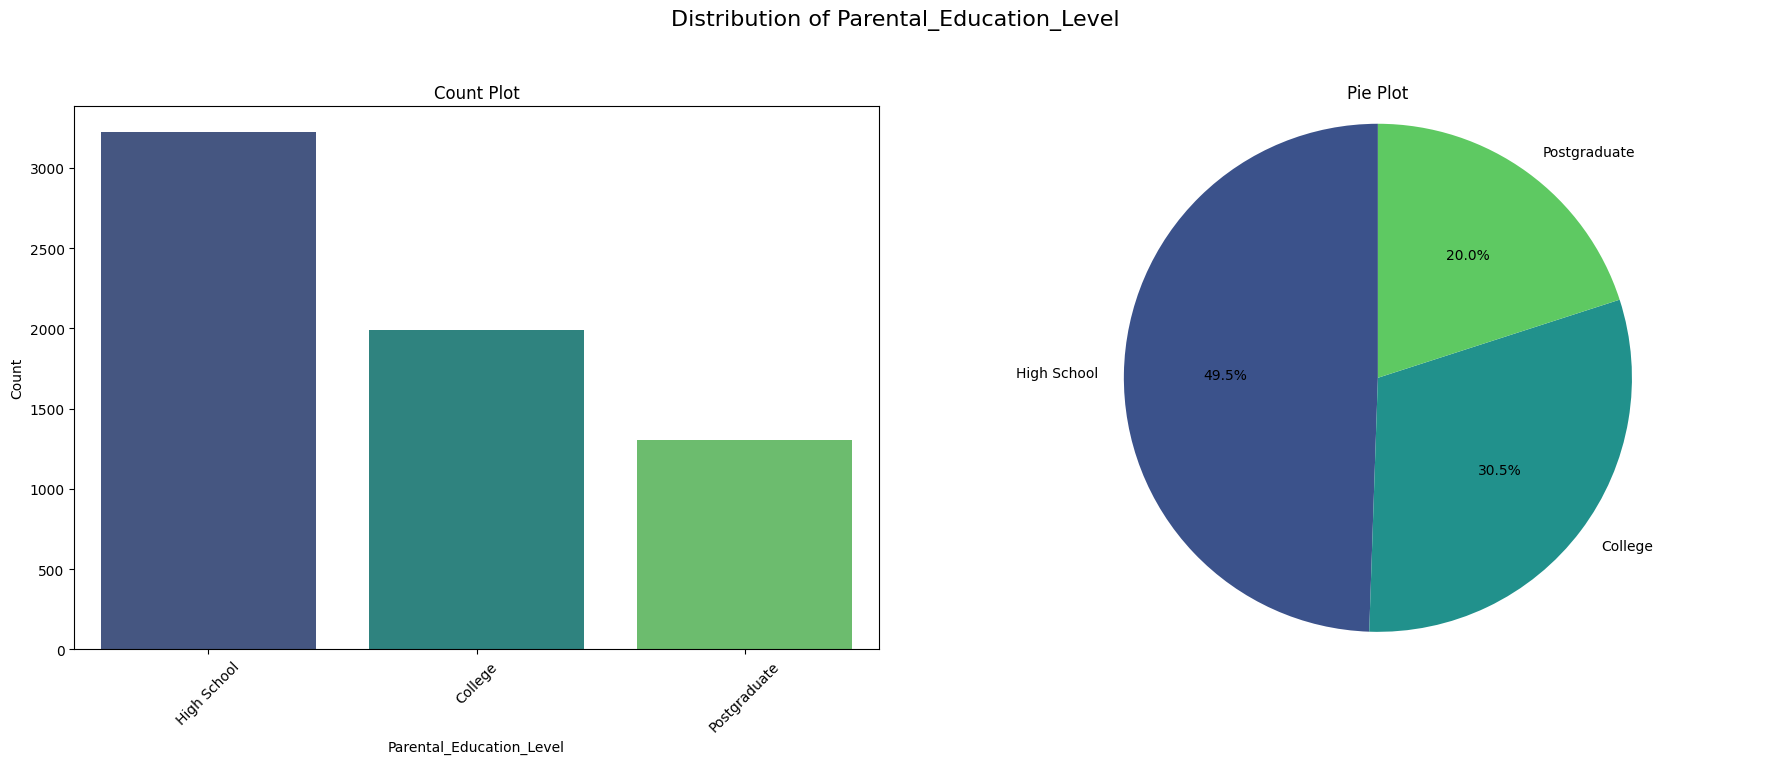

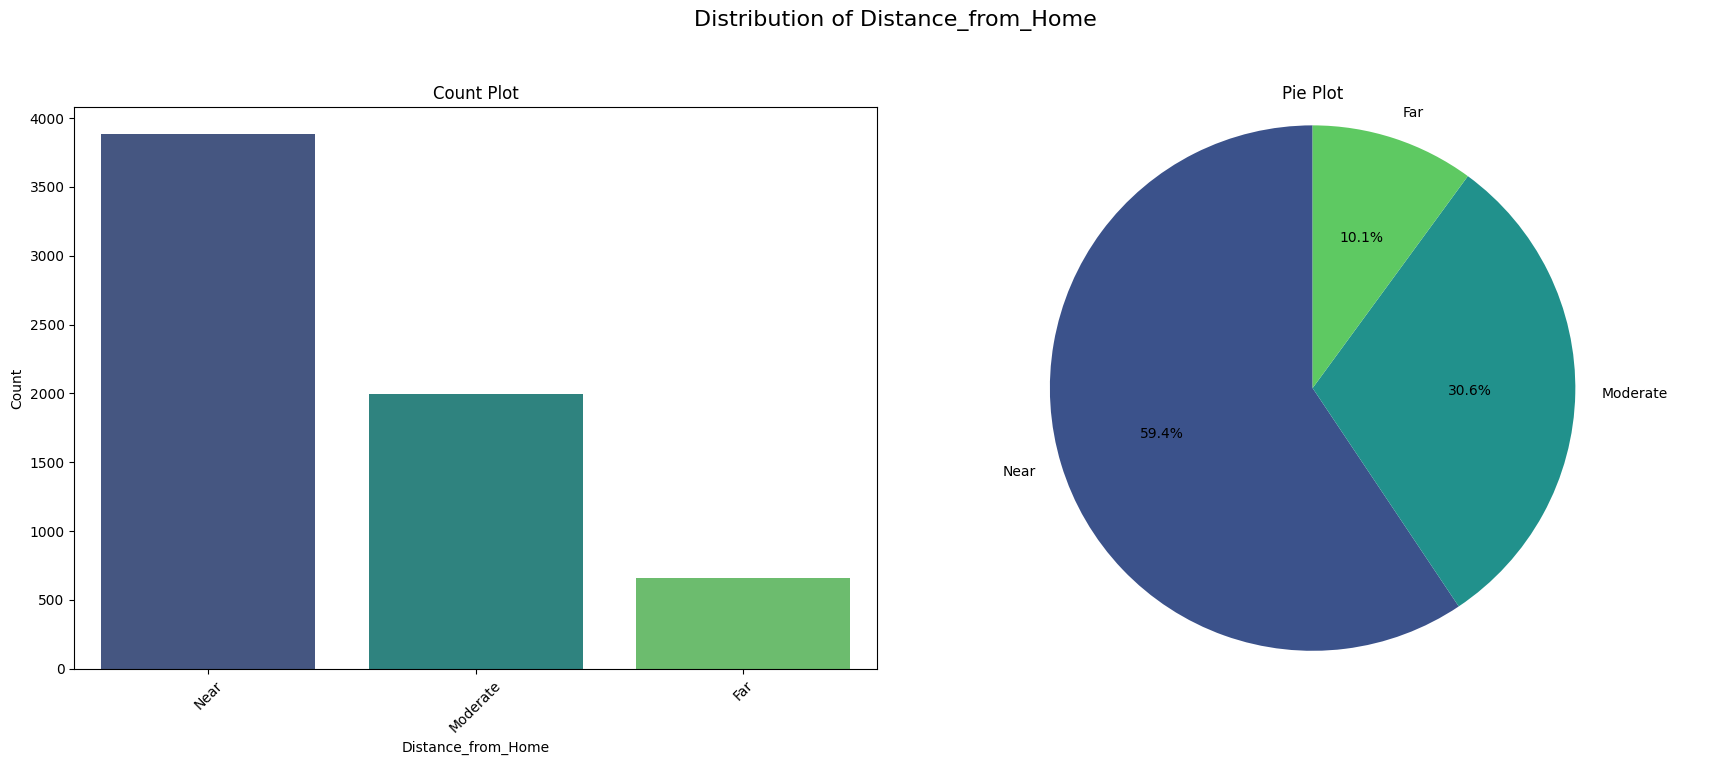

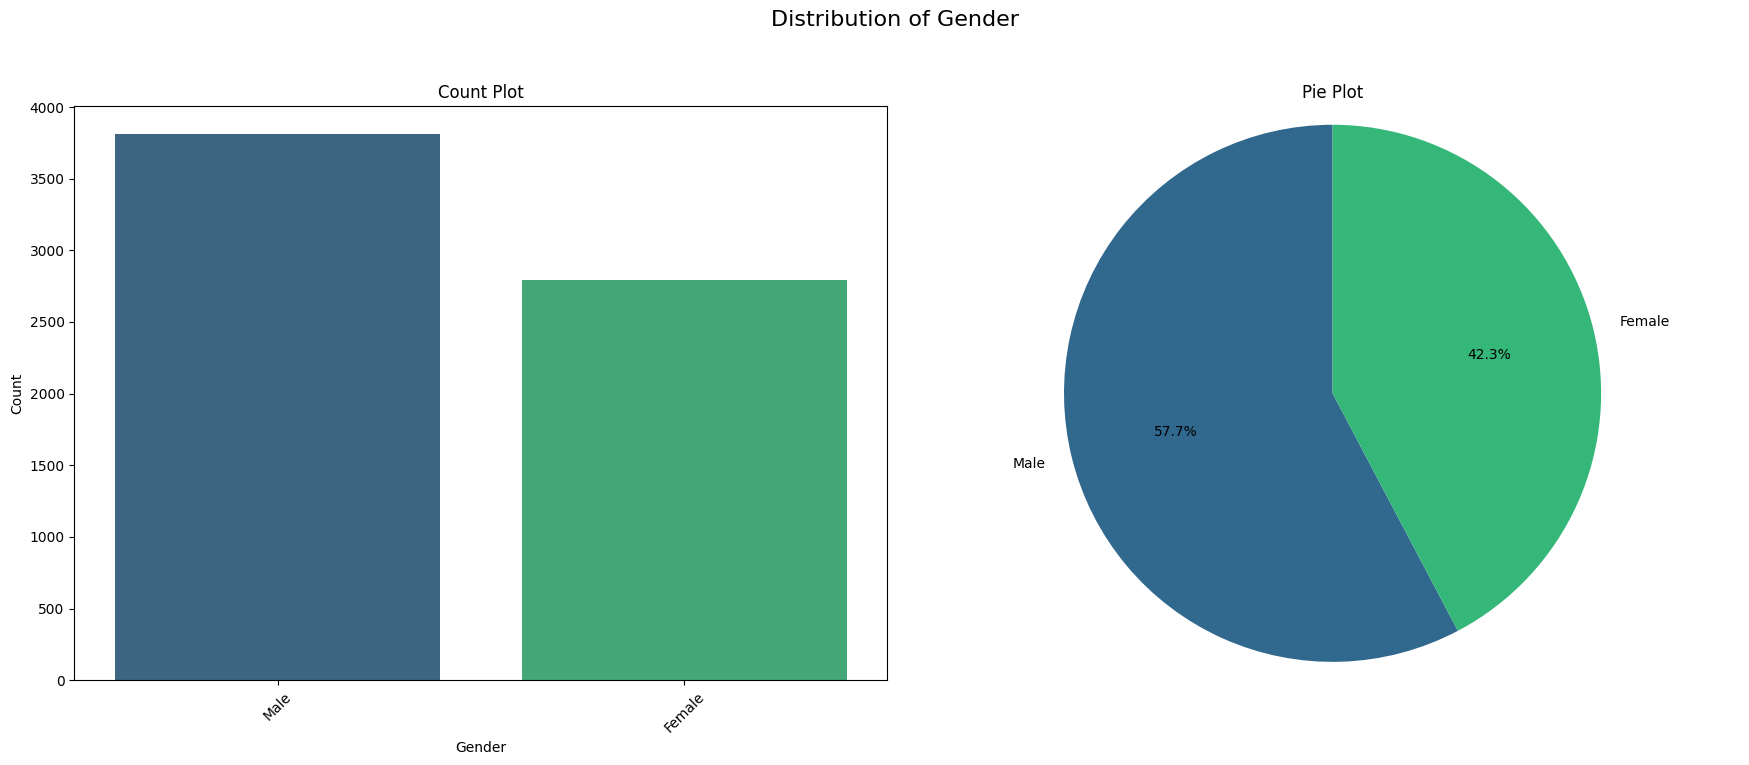

In [65]:
for col in cat_cols:
  plot_categorical_distribution(col)

In [66]:
def display_categorical_unique_values(df=df):
    cat_cols = df.select_dtypes(include='object').columns

    if len(cat_cols) == 0:
        print("No categorical columns found in the DataFrame.")
        return

    print("--- Unique Values in Categorical Columns ---")
    for col in cat_cols:
        unique_values = df[col].unique()
        num_unique = len(unique_values)
        print(f"\nColumn: {col}")
        print(f"Number of unique values: {num_unique}")
        print(f"Unique values: {unique_values}")
    print("\n-------------------------------------------")

In [67]:
display_categorical_unique_values()

--- Unique Values in Categorical Columns ---

Column: Parental_Involvement
Number of unique values: 3
Unique values: ['Low' 'Medium' 'High']

Column: Access_to_Resources
Number of unique values: 3
Unique values: ['High' 'Medium' 'Low']

Column: Extracurricular_Activities
Number of unique values: 2
Unique values: ['No' 'Yes']

Column: Motivation_Level
Number of unique values: 3
Unique values: ['Low' 'Medium' 'High']

Column: Internet_Access
Number of unique values: 2
Unique values: ['Yes' 'No']

Column: Family_Income
Number of unique values: 3
Unique values: ['Low' 'Medium' 'High']

Column: Teacher_Quality
Number of unique values: 4
Unique values: ['Medium' 'High' 'Low' nan]

Column: School_Type
Number of unique values: 2
Unique values: ['Public' 'Private']

Column: Peer_Influence
Number of unique values: 3
Unique values: ['Positive' 'Negative' 'Neutral']

Column: Learning_Disabilities
Number of unique values: 2
Unique values: ['No' 'Yes']

Column: Parental_Education_Level
Number of uni

Oridinal Encoding = ['Parental_Involvement', 'Access_to_Resources', 'Motivation_Level', 'Family_Income', 'Teacher_Quality','Parental_Education_Level', 'Distance_from_Home']

Lable Encoding = ['Extracurricular_Activities', 'Internet_Access', 'School_Type', 'Learning_Disabilities', 'Gender']

One Hot Encoding = ['Peer_Influence']

In [69]:
def plot_scatter_with_regression(column_name, target_column='Exam_Score', df=df):
    if column_name not in df.columns:
        print(f"Error: Column '{column_name}' not found in the DataFrame.")
        return
    if target_column not in df.columns:
        print(f"Error: Target column '{target_column}' not found in the DataFrame.")
        return

    plt.figure(figsize=(10, 6))
    sns.regplot(data=df, x=column_name, y=target_column, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    plt.title(f'Scatter Plot of {column_name} vs {target_column}', fontsize=16)
    plt.xlabel(column_name, fontsize=12)
    plt.ylabel(target_column, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

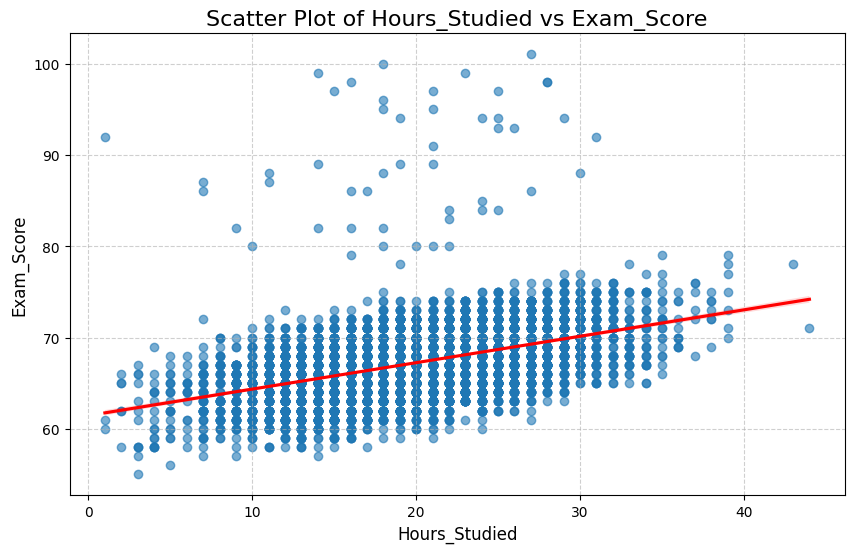

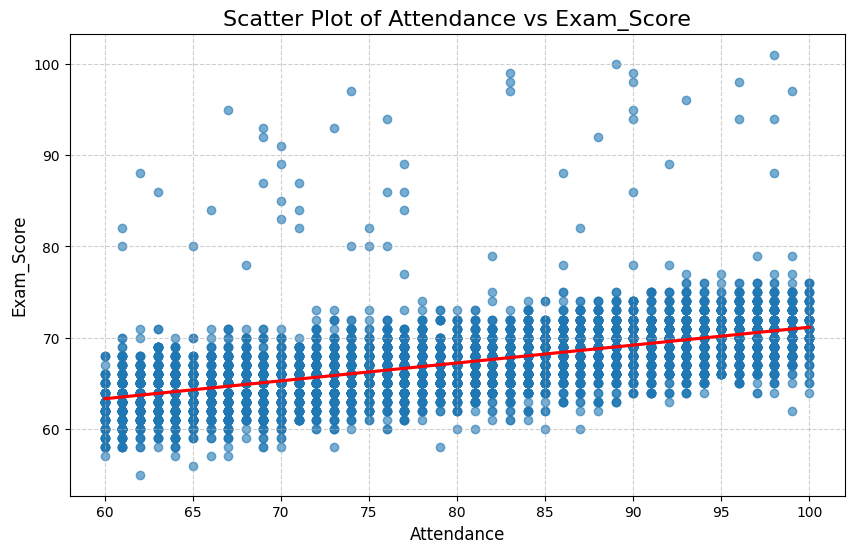

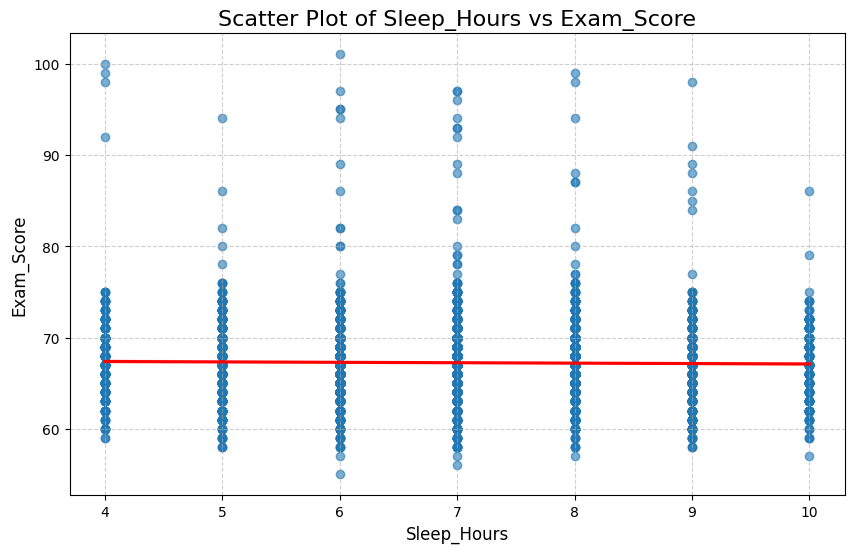

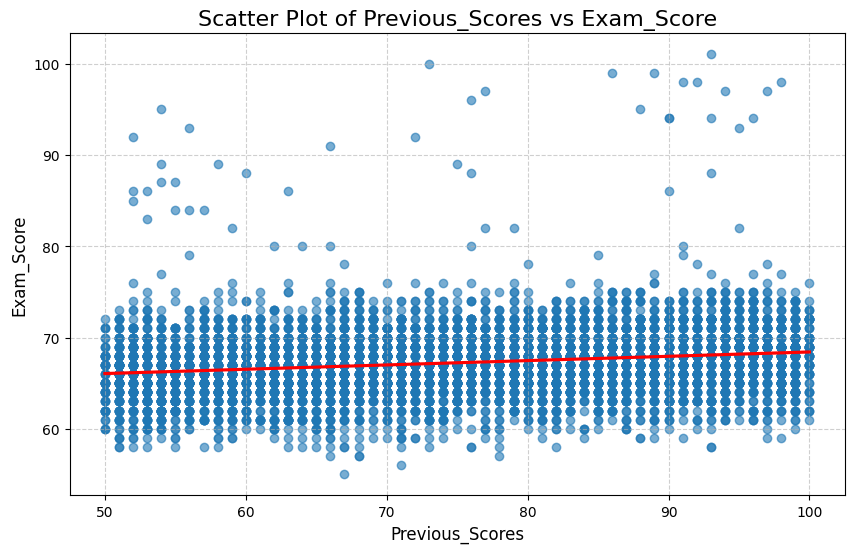

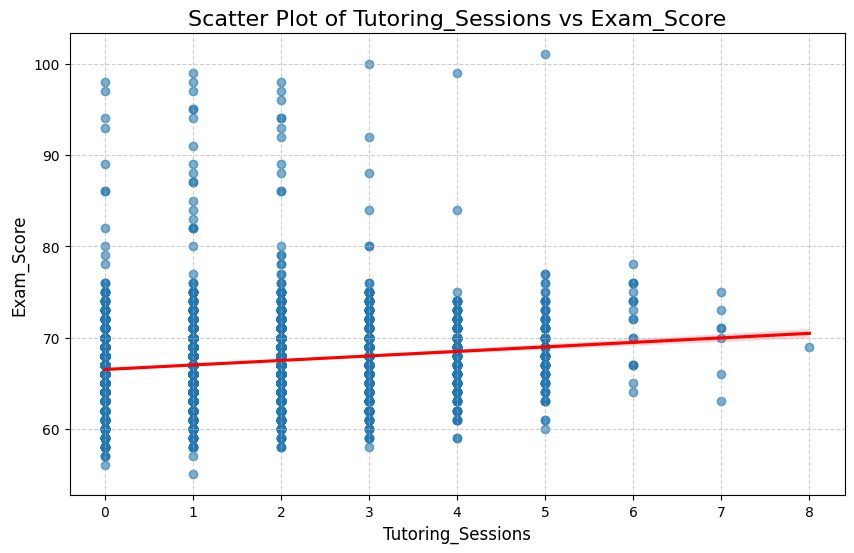

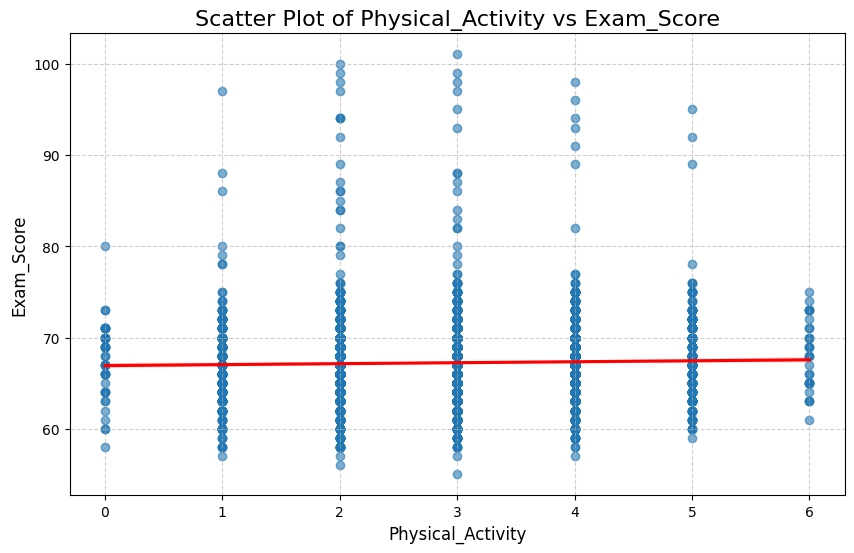

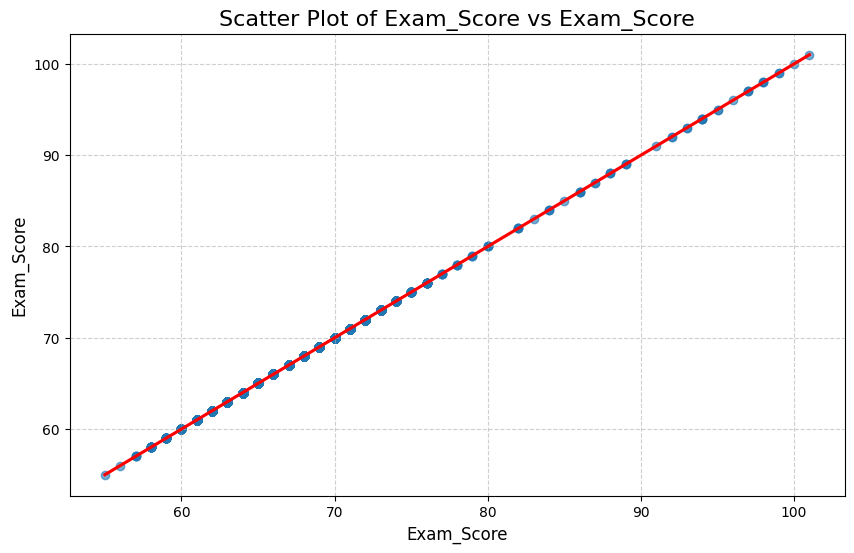

In [70]:
for col in num_cols:
  plot_scatter_with_regression(col)

## Data Preprocessing

Perform data preprocessing steps.

In [71]:
# Splitting dataset into train and test before anything.
# Its mainly because preventing data leakage.

X = df.drop('Exam_Score', axis=1)
y = df['Exam_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [83]:
ord_columns = ['Parental_Involvement', 'Access_to_Resources', 'Motivation_Level', 'Family_Income', 'Teacher_Quality','Parental_Education_Level', 'Distance_from_Home']
hot_columns = ['Extracurricular_Activities', 'Internet_Access', 'School_Type', 'Learning_Disabilities', 'Gender', 'Peer_Influence']
num_columns = df.select_dtypes(include='number').drop('Exam_Score', axis=1).columns.tolist()

ordinal_categories = [
    ['Low', 'Medium', 'High'],                  # Parental_Involvement
    ['Low', 'Medium', 'High'],                  # Access_to_Resources
    ['Low', 'Medium', 'High'],                  # Motivation_Level
    ['Low', 'Medium', 'High'],                  # Family_Income
    ['Low', 'Medium', 'High'],                  # Teacher_Quality
    ['High School', 'College', 'Postgraduate'], # Parental_Education_Level
    ['Near', 'Moderate', 'Far']                 # Distance_from_Home
]

ord_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=ordinal_categories))
])

hot_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

num_transformer = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', RobustScaler())
])

preprocessor = ColumnTransformer([
    ('ord', ord_transformer, ord_columns),
    ('hot', hot_transformer, hot_columns),
    ('num', num_transformer, num_columns)
])

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

## Model Selection

Compare and select the best regression model.

In [89]:
def evaluate_model(y_true, y_pred, model_name=''):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"Model: {model_name}")
    print(f"Mean Squared Error: {mse:.2f}")
    print(f"Root Mean Squared Error: {np.sqrt(mse)}")
    print(f"Mean Absolute Error: {mae:.2f}")
    print(f"R-squared: {r2 * 100:.2f}%")
    print('\n')

    return mse, np.sqrt(mse), mae, r2

In [91]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Lasso Regression': Lasso(alpha=0.1, max_iter=1000, random_state=42),
    'Elastic Net Regression': ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42),
    'K-Nearest Neighbors': KNeighborsRegressor(n_neighbors=5, weights='distance'),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Support Vector Machine': SVR(kernel='rbf', C=100, epsilon=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42),
    'AdaBoost': AdaBoostRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, objective='reg:squarederror', random_state=42, n_jobs=-1),
    'LightGBM': LGBMRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, verbosity=-1, random_state=42, n_jobs=-1)
}

results = {}
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse, rmse, mae, r2 = evaluate_model(y_test, y_pred, model_name)
    results[model_name] = {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

Model: Linear Regression
Mean Squared Error: 3.24
Root Mean Squared Error: 1.8002032879431895
Mean Absolute Error: 0.45
R-squared: 77.07%


Model: Ridge Regression
Mean Squared Error: 3.24
Root Mean Squared Error: 1.8001523510865125
Mean Absolute Error: 0.45
R-squared: 77.07%


Model: Lasso Regression
Mean Squared Error: 3.64
Root Mean Squared Error: 1.9073068518809382
Mean Absolute Error: 0.75
R-squared: 74.26%


Model: Elastic Net Regression
Mean Squared Error: 3.62
Root Mean Squared Error: 1.9036680179939742
Mean Absolute Error: 0.74
R-squared: 74.36%


Model: K-Nearest Neighbors
Mean Squared Error: 6.32
Root Mean Squared Error: 2.51330397310398
Mean Absolute Error: 1.56
R-squared: 55.31%


Model: Decision Tree
Mean Squared Error: 8.26
Root Mean Squared Error: 2.8738522212768323
Mean Absolute Error: 1.56
R-squared: 41.57%


Model: Support Vector Machine
Mean Squared Error: 3.51
Root Mean Squared Error: 1.8729748239915902
Mean Absolute Error: 0.59
R-squared: 75.18%


Model: Random Fo

In [95]:
pd.DataFrame(results).T.sort_values(by='R2', ascending=False)

,MSE,RMSE,MAE,R2
Ridge Regression,3.24,1.80,0.45,0.77
Linear Regression,3.24,1.80,0.45,0.77
Support Vector Machine,3.51,1.87,0.59,0.75
LightGBM,3.61,1.90,0.74,0.74
Elastic Net Regression,3.62,1.90,0.74,0.74
Lasso Regression,3.64,1.91,0.75,0.74
XGBoost,3.70,1.92,0.75,0.74
Gradient Boosting,3.81,1.95,0.76,0.73
Random Forest,4.82,2.20,1.15,0.66
K-Nearest Neighbors,6.32,2.51,1.56,0.55


## Model Training

Train the selected model.

In [97]:
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train, y_train)

Ridge(random_state=42)

In [101]:
cross_val_scores = cross_val_score(ridge, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
print(f"Cross-Validation Scores: {cross_val_scores}")
print(f"Mean Cross-Validation Score: {-cross_val_scores.mean():.2f}")

Cross-Validation Scores: [-2.64112293 -2.63269315 -4.0854316  -4.75143319 -7.87325848]
Mean Cross-Validation Score: 4.40


## Model Fine-tuning

Fine-tune hyperparameters using Grid Search and Cross-Validation.

In [103]:
ridge = Ridge()

param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100],
    'solver': ['auto', 'saga', 'lsqr', 'sparse_cg'],
    'fit_intercept': [True, False],
    'max_iter': [1000, 5000]
}

grid_search = GridSearchCV(estimator=ridge, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.01, 0.1, 1, 10, 100],
                         'fit_intercept': [True, False],
                         'max_iter': [1000, 5000],
                         'solver': ['auto', 'saga', 'lsqr', 'sparse_cg']},
             scoring='neg_mean_squared_error')

In [104]:
best_model = grid_search.best_estimator_
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print(f"Best Model: {best_model}")
print(f"Best Parameters: {best_params}")
print(f"Best Cross-Validation Score: {-best_score:.2f}")

Best Model: Ridge(alpha=1, max_iter=1000, solver='lsqr')
Best Parameters: {'alpha': 1, 'fit_intercept': True, 'max_iter': 1000, 'solver': 'lsqr'}
Best Cross-Validation Score: 4.40


## Prediction

Use the final model for prediction.

In [106]:
y_train_pred = best_model.predict(X_train)
evaluate_model(y_train, y_train_pred, "Ridge Model (Train Dataset)")

Model: Ridge Model (Train Dataset)
Mean Squared Error: 4.35
Root Mean Squared Error: 2.0865314878911247
Mean Absolute Error: 0.49
R-squared: 71.69%




(4.35361364996115,
 np.float64(2.0865314878911247),
 0.49406500605776255,
 0.7169479132768347)

In [107]:
y_test_pred = best_model.predict(X_test)
evaluate_model(y_test, y_test_pred, "Ridge Model (Test Dataset)")

Model: Ridge Model (Test Dataset)
Mean Squared Error: 3.24
Root Mean Squared Error: 1.8001744083885445
Mean Absolute Error: 0.45
R-squared: 77.07%




(3.2406279006170458,
 np.float64(1.8001744083885445),
 0.44572274233326076,
 0.770738501214315)

In [112]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [113]:
sample = pd.DataFrame([{
    'Hours_Studied': 19,
    'Attendance': 92,
    'Parental_Involvement': 'Medium',
    'Access_to_Resources': 'Medium',
    'Extracurricular_Activities': 'Yes',
    'Sleep_Hours': 6,
    'Previous_Scores': 65,
    'Motivation_Level': 'Medium',
    'Internet_Access': 'Yes',
    'Tutoring_Sessions': 3,
    'Family_Income': 'Medium',
    'Teacher_Quality': 'High',
    'School_Type': 'Public',
    'Peer_Influence': 'Neutral',
    'Physical_Activity': 4,
    'Learning_Disabilities': 'No',
    'Parental_Education_Level': 'College',
    'Distance_from_Home': 'Near',
    'Gender': 'Female'
}])

sample = preprocessor.transform(sample)

predicted_score = best_model.predict(sample)
print(f"Predicted Exam Score: {predicted_score[0]:.2f}")

Predicted Exam Score: 70.94
